# Right Tool, Right Job?
## Decoding AI Adoption Patterns Among IIT Students

| Component | Technique | Target |
|-----------|-----------|--------|
| Clustering | K-Means | User archetypes |
| Regression | Ridge Regression | Hours saved per week |
| Classification | Decision Tree | Primary tool (Claude / ChatGPT / Other) |
| Visualization | Plotly / Seaborn | Tool × Use-case patterns |


> **Dataset**: Primary survey collected from IIT students, April 8–10 2026. N = 65 responses.

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')


In [3]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, classification_report, silhouette_score
from sklearn.model_selection import cross_val_score
from sklearn.decomposition import PCA
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

---
## 1. Data Collection

| Field | Detail |
|-------|--------|
| Source | Google Forms, self-administered primary survey |
| Population | IIT students (predominantly IIT Bhilai) |
| Collection Period | April 8–10, 2026 |
| Total Responses | 65 |
| Method | Voluntary, anonymous |
| Questions | 16, covering demographics, tool usage, use cases, ethics, trust |

In [4]:
df_raw = pd.read_csv('survey.csv')
print(f"Shape: {df_raw.shape}")
df_raw.head(3)

Shape: (66, 17)


,Timestamp,(1) What is your current year of study?,(2) What is your primary field of study?,(3) What is your gender?,(4) What type of institution are you currently enrolled in?,"(5) How long have you been using AI tools (e.g., ChatGPT, Gemini, Copilot, etc.)?",(6) Which was the first AI tool you ever used?,(7) Which AI tool do you use most frequently right now?,(8) Which AI tools have you used in the last 30 days? (Select all that apply),(9) What are your primary use cases for AI tools in your academic life? (Select all that apply),(10) What is your average usage frequency of AI tools?,(11) Approximately how many hours do AI tools save you per week on academic tasks?,(12) To what extent do you generally trust the outputs/answers generated by AI tools for academic purposes?,"(13) Regarding AI tool subscriptions (e.g., ChatGPT Plus, Gemini Advanced, etc.):","(14) Have you ever submitted content generated entirely by AI (e.g., essays, code blocks) as your own work without significant modification or citation?","(15) How concerned are you that the increasing reliance on AI tools might devalue or atrophy core academic/professional skills (e.g., critical thinking, writing, coding)?","(16) On a scale of 0 to 10, how likely are you to recommend the use of AI tools to a peer or junior student?"
0,2026/04/08 7:47:05 PM GMT+5:30,2nd,Data Science & AI,Male,IIT,2+ years,ChatGPT,Claude,ChatGPT;Claude;Gemini;Grok;Stable Diffusion;Gi...,Coding & debugging;Assignments & homework (con...,Multiple times a day,6–10 hours,4.0,"No, I only use free tiers/models",Often,3.0,9.0
1,2026/04/08 7:52:32 PM GMT+5:30,2nd,Data Science & AI,Male,IIT,2+ years,ChatGPT,Gemini (or Google Bard),ChatGPT;Claude;Gemini;Grok;GitHub Copilot;Cursor,Coding & debugging;Assignments & homework (con...,Multiple times a day,More than 10 hours,5.0,"Yes, I pay for a subscription myself",Sometimes,3.0,8.0
2,2026/04/08 7:52:48 PM GMT+5:30,2nd,Data Science & AI,Male,IIT,1–2 years,ChatGPT,Claude,ChatGPT;Claude;Gemini;Perplexity;DeepSeek,Coding & debugging;Assignments & homework (con...,Multiple times a day,3–5 hours,3.0,"Yes, my institution/scholarship pays for my su...",Never,2.0,4.0


---
## 2. Data Cleaning & Preparation

### Cleaning Steps

| Step | Action |
|------|--------|
| Column rename | Short readable names |
| Joke responses | Drop rows with clearly inappropriate fields (e.g. 'boyfriend', 'v@@gin se@') |
| Blank rows | Drop rows with no year/field |
| Multi-select columns | Explode semicolon lists → boolean columns per tool / use-case |
| Ordinal encoding | Frequency, hours saved → numeric |
| Target encoding | Primary tool → 3-class label |

In [5]:
df_raw.columns = [
    'timestamp','year','field','gender','institution',
    'exp','first_tool','primary_tool','tools_used','use_cases',
    'freq','hours_saved','trust','subscription','submitted_ai',
    'skill_concern','nps'
]
df = df_raw.copy()

In [6]:
# invalid rows hatao 
joke_keywords = ['boyfriend','virgin','siri']
mask = df['field'].str.lower().apply(lambda x: any(k in str(x) for k in joke_keywords))
mask |= df['year'].isna()
mask |= df['first_tool'].str.lower().apply(lambda x: any(k in str(x) for k in joke_keywords))

df = df[~mask].reset_index(drop=True)
print(f"Rows after cleaning: {len(df)}")

Rows after cleaning: 62


In [7]:
freq_map = {
    'Rarely': 1, 'A few times a week': 2,
    'Once a day': 3, 'Multiple times a day': 4
}
hours_map = {
    '0 hours': 0, '1–2 hours': 1.5, '3–5 hours': 4,
    '6–10 hours': 8, 'More than 10 hours': 12
}
exp_map = {
    'Never used': 0, '3–6 months': 0.5,
    '6–12 months': 0.75, '1–2 years': 1.5, '2+ years': 2.5
}
sub_map = {
    'No, I only use free tiers/models': 0,
    'Yes, I pay for a subscription myself': 2,
    'Yes, my institution/scholarship pays for my subscription': 1
}
ethics_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Often': 3, 'Prefer not to say': np.nan}

df['freq_n']    = df['freq'].map(freq_map)
df['hours_n']   = df['hours_saved'].map(hours_map)
df['exp_n']     = df['exp'].map(exp_map)
df['sub_n']     = df['subscription'].map(sub_map)
df['ethics_n']  = df['submitted_ai'].map(ethics_map)
df['trust']     = pd.to_numeric(df['trust'], errors='coerce')
df['concern']   = pd.to_numeric(df['skill_concern'], errors='coerce')
df['nps']       = pd.to_numeric(df['nps'], errors='coerce')

In [9]:
ALL_TOOLS = [
    'ChatGPT','Claude','Gemini','Microsoft Copilot','GitHub Copilot',
    'Perplexity','Grok','DeepSeek','Cursor','Notion AI','Grammarly AI',
    'DALL·E','Midjourney','Stable Diffusion','Suno','ElevenLabs'
]
ALL_CASES = [
    'Coding & debugging',
    'Assignments & homework (conceptual help)',
    'Studying concepts/explaining difficult topics',
    'Writing & essays (proofreading, idea generation)',
    'Research & summarization',
    'Image/video generation (creative projects)',
    'Career prep (e.g., mock interviews, resume review)',
    'Productivity (e.g., scheduling, email drafts)',
    'Entertainment'
]


In [10]:
for t in ALL_TOOLS:
    df[f't_{t}'] = df['tools_used'].str.contains(t, na=False).astype(int)

for c in ALL_CASES:
    col = 'uc_' + c.split('(')[0].strip().replace(' & ','_').replace(' ','_').replace('/','_')
    df[col] = df['use_cases'].str.contains(c, na=False).astype(int)

df['tool_count'] = df[[f't_{t}' for t in ALL_TOOLS]].sum(axis=1)
df['usecase_count'] = df[['uc_' + c.split('(')[0].strip().replace(' & ','_').replace(' ','_').replace('/','_') for c in ALL_CASES]].sum(axis=1)
print("New feature columns created:", df['tool_count'].describe().to_dict())

New feature columns created: {'count': 62.0, 'mean': 4.306451612903226, 'std': 2.2730690575174473, 'min': 0.0, '25%': 3.0, '50%': 4.0, '75%': 6.0, 'max': 9.0}


In [11]:
def map_primary(t):
    t = str(t).strip()
    if 'Claude' in t: return 'Claude'
    if 'ChatGPT' in t: return 'ChatGPT'
    return 'Other'

In [13]:
df['tool_label'] = df['primary_tool'].apply(map_primary)
df['tool_label'].value_counts()

tool_label
ChatGPT    31
Other      18
Claude     13
Name: count, dtype: int64

---
## 3. Exploratory Data Analysis

### 3.1 — Demographics Overview

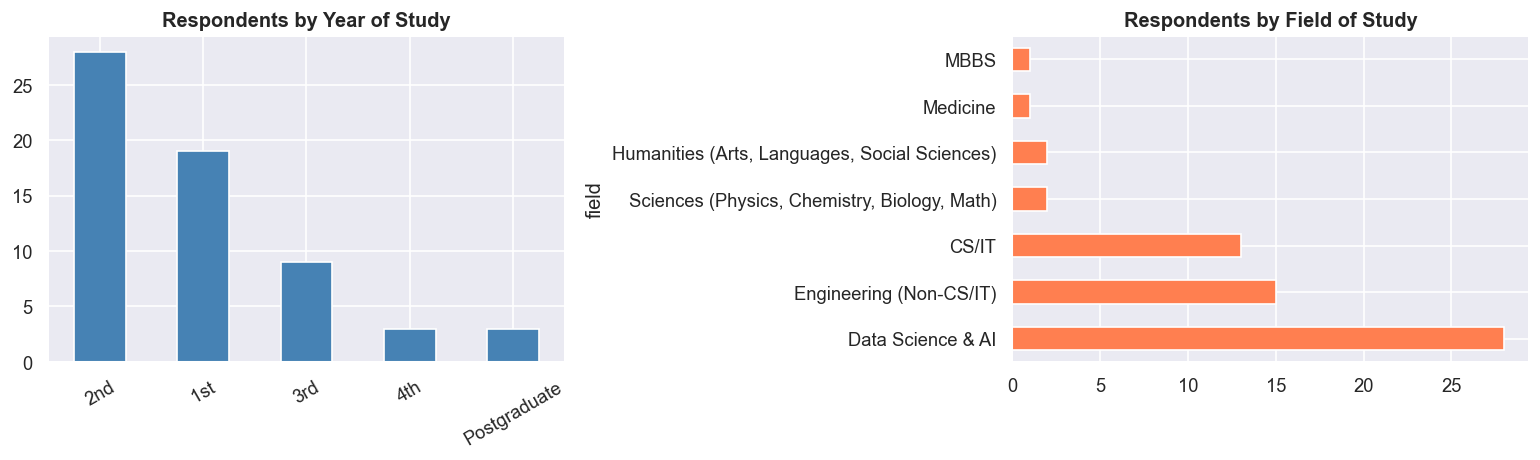

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['year'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Respondents by Year of Study', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

df['field'].value_counts().plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Respondents by Field of Study', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_demographics.png', bbox_inches='tight')
plt.show()

### 3.2 — Tool Popularity & First Tool Loyalty

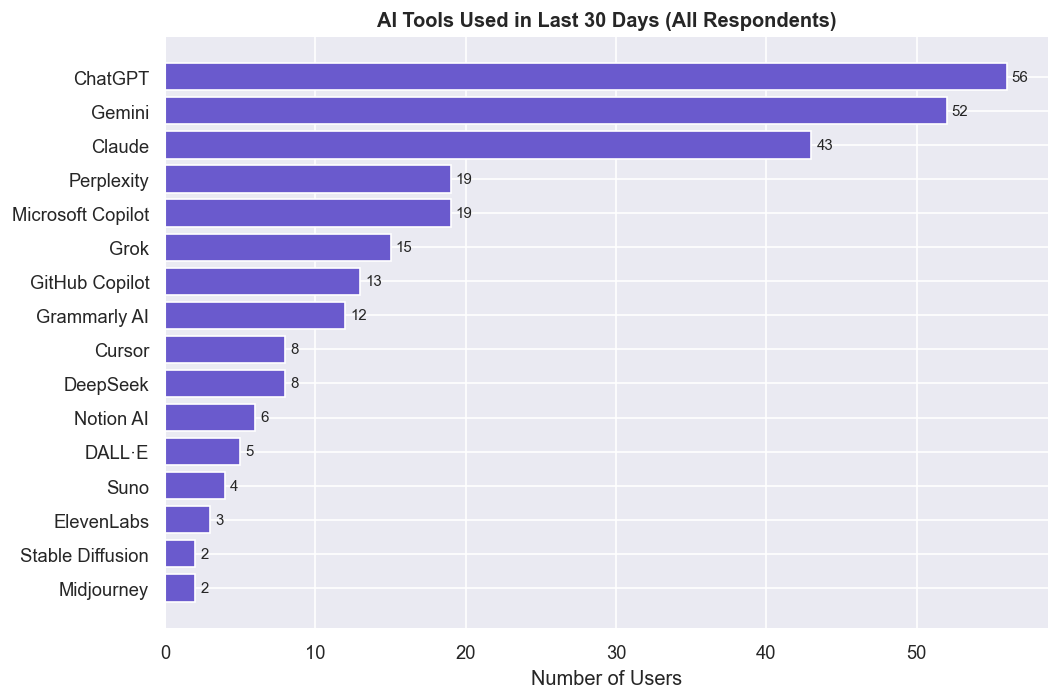

In [15]:
tool_counts = {t: df[f't_{t}'].sum() for t in ALL_TOOLS}
tool_df = pd.DataFrame({'tool': list(tool_counts.keys()), 'users': list(tool_counts.values())})
tool_df = tool_df[tool_df['users'] > 0].sort_values('users', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(tool_df['tool'], tool_df['users'], color='slateblue', edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title('AI Tools Used in Last 30 Days (All Respondents)', fontweight='bold')
ax.set_xlabel('Number of Users')
plt.tight_layout()
plt.savefig('eda_tool_popularity.png', bbox_inches='tight')
plt.show()

In [20]:
primary_counts = df['tool_label'].value_counts()

fig = px.pie(
    values=primary_counts.values,
    names=primary_counts.index,
    title='Primary Tool Distribution',
    color_discrete_sequence=px.colors.qualitative.Set2,
    hole=0.4
)
fig.update_traces(textinfo='percent+label')
fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [21]:
pip install nbformat --upgrade

Note: you may need to restart the kernel to use updated packages.


### 3.3 — Tool × Use Case Heatmap
> Ye project ka centerpiece visualization hai — kaun sa tool kisliye use ho raha hai

In [ ]:
# --- tool x use case heatmap ---
uc_cols = ['uc_Coding_debugging','uc_Assignments_homework','uc_Studying_concepts_explaining_difficult_topics',
           'uc_Writing_essays','uc_Research_summarization','uc_Image_video_generation',
           'uc_Career_prep','uc_Productivity','uc_Entertainment']

uc_labels = ['Coding','Assignments','Study/Explain','Writing','Research',
             'Image Gen','Career Prep','Productivity','Entertainment']

focus_tools = ['ChatGPT','Claude','Gemini','GitHub Copilot','Perplexity','DeepSeek','Cursor','Grammarly AI']

heatmap_data = []
for tool in focus_tools:
    tool_users = df[df[f't_{tool}'] == 1]
    row = [tool_users[col].sum() for col in uc_cols]
    heatmap_data.append(row)

hm_df = pd.DataFrame(heatmap_data, index=focus_tools, columns=uc_labels)

plt.figure(figsize=(13, 6))
sns.heatmap(hm_df, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Number of users'})
plt.title('Tool × Use Case Heatmap\n(How many users of each tool use it for each purpose)', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight')
plt.show()

### 3.4 — First Tool → Current Tool (Loyalty / Migration)

In [ ]:
# --- sankey ke liye source-target pairs ---
def clean_tool(t):
    t = str(t).strip()
    if 'ChatGPT' in t: return 'ChatGPT'
    if 'Claude' in t: return 'Claude'
    if 'Gemini' in t or 'Bard' in t: return 'Gemini'
    if 'Grammarly' in t: return 'Grammarly'
    if 'Copilot' in t: return 'Copilot'
    if 'Perplexity' in t: return 'Perplexity'
    if "Haven't" in t or 'Never' in t: return 'None'
    return 'Other'

df['first_clean']   = df['first_tool'].apply(clean_tool)
df['current_clean'] = df['primary_tool'].apply(clean_tool)

flow = df.groupby(['first_clean','current_clean']).size().reset_index(name='count')
flow = flow[flow['count'] >= 1]

all_nodes = list(pd.unique(flow[['first_clean','current_clean']].values.ravel()))
node_idx  = {n: i for i, n in enumerate(all_nodes)}

fig = go.Figure(go.Sankey(
    node=dict(label=all_nodes, pad=15, thickness=20,
              color='rgba(99,110,250,0.8)'),
    link=dict(
        source=[node_idx[r] for r in flow['first_clean']],
        target=[node_idx[r] for r in flow['current_clean']],
        value=flow['count'].tolist()
    )
))
fig.update_layout(title='First Tool → Current Primary Tool Migration', font_size=12, height=500)
fig.show()

### 3.5 — Trust, Concern & Ethics Distribution

In [ ]:
# --- trust vs skill concern scatter ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['trust'].dropna(), bins=5, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Trust in AI Output (1–5)', fontweight='bold')

axes[1].hist(df['concern'].dropna(), bins=5, color='tomato', edgecolor='white')
axes[1].set_title('Skill Atrophy Concern (1–5)', fontweight='bold')

ethics_counts = df['submitted_ai'].value_counts()
axes[2].bar(ethics_counts.index, ethics_counts.values, color='mediumpurple', edgecolor='white')
axes[2].set_title('Submitted AI Content As Own Work?', fontweight='bold')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('eda_trust_ethics.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- hours saved violin by primary tool ---
violin_df = df[df['tool_label'].isin(['Claude','ChatGPT','Other']) & df['hours_n'].notna()]

fig = px.violin(
    violin_df, y='hours_n', x='tool_label', box=True, points='all',
    color='tool_label', title='Hours Saved per Week — by Primary Tool',
    labels={'hours_n': 'Hours Saved / Week', 'tool_label': 'Primary Tool'},
    color_discrete_sequence=px.colors.qualitative.Pastel
)
fig.show()

### 3.6 — Use Case Breakdown by Field of Study

In [ ]:
# --- field wise use case stacked bar ---
main_fields = ['Data Science & AI','CS/IT','Engineering (Non-CS/IT)']
field_df = df[df['field'].isin(main_fields)]

uc_by_field = field_df.groupby('field')[uc_cols].sum()
uc_by_field.columns = uc_labels

uc_by_field.T.plot(kind='bar', figsize=(13, 5), colormap='tab10', edgecolor='white')
plt.title('Use Case Frequency by Field of Study', fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Count of Users')
plt.legend(title='Field', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('eda_usecase_field.png', bbox_inches='tight')
plt.show()

### 3.7 — Correlation Heatmap (Behavioral Features)

In [ ]:
# --- behavioral features correlation ---
corr_cols = ['freq_n','hours_n','trust','concern','tool_count','usecase_count','exp_n','sub_n','ethics_n','nps']
corr_labels = ['Frequency','Hours Saved','Trust','Skill Concern','Tool Count','UseCase Count','Experience','Subscription','Ethics','NPS']

corr_df = df[corr_cols].dropna()
corr_df.columns = corr_labels

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix — Behavioral Features', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

---
## 4. Clustering — Finding User Archetypes

| Feature | Why included |
|---------|-------------|
| freq_n | How often they use AI |
| hours_n | How much they extract from it |
| tool_count | Breadth of AI ecosystem knowledge |
| usecase_count | Depth of integration into academic life |
| trust | Epistemic stance toward AI |
| sub_n | Willingness to invest monetarily |

In [ ]:
# --- clustering features prepare karo ---
cluster_cols = ['freq_n','hours_n','tool_count','usecase_count','trust','sub_n']
cluster_df   = df[cluster_cols].dropna()
cluster_idx  = cluster_df.index

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(cluster_df)
print(f"Clustering on {len(cluster_df)} clean rows")

In [ ]:
# --- elbow + silhouette: sahi k dhundo ---
inertias, silhouettes = [], []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouettes, 'rs-')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Score')

plt.tight_layout()
plt.savefig('cluster_elbow.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- final k=3 fit karo ---
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df.loc[cluster_idx, 'cluster'] = km_final.fit_predict(X_scaled)
df['cluster'] = df['cluster'].fillna(-1).astype(int)

In [ ]:
# --- cluster profiles dekhte hain ---
profile = df[df['cluster'] >= 0].groupby('cluster')[cluster_cols].mean().round(2)
profile.index = ['Cluster 0','Cluster 1','Cluster 2']
print(profile.to_markdown())

In [ ]:
# --- radar chart — har cluster ka fingerprint ---
cluster_names = {0: 'Pragmatist', 1: 'Power User', 2: 'Skeptic/Casual'}
colors = ['steelblue','tomato','mediumseagreen']
categories = ['Frequency','Hours Saved','Tool Count','UseCase Count','Trust','Subscription']

fig = go.Figure()
for cid in [0, 1, 2]:
    vals = profile.iloc[cid].tolist()
    vals_norm = [(v - profile[col].min()) / (profile[col].max() - profile[col].min() + 1e-6)
                 for v, col in zip(vals, cluster_cols)]
    vals_norm += [vals_norm[0]]
    cats = categories + [categories[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals_norm, theta=cats,
        fill='toself', name=cluster_names[cid]
    ))

fig.update_layout(title='Cluster Radar — Behavioral Fingerprints',
                  polar=dict(radialaxis=dict(visible=True, range=[0,1])))
fig.show()

In [ ]:
# --- PCA se 2D mein visualize karo ---
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_plot = pd.DataFrame({'PC1': X_pca[:,0], 'PC2': X_pca[:,1],
                          'Cluster': [cluster_names.get(c,'?') for c in df.loc[cluster_idx,'cluster']]})

fig = px.scatter(pca_plot, x='PC1', y='PC2', color='Cluster',
                 title='PCA — Cluster Separation (2D Projection)',
                 color_discrete_sequence=px.colors.qualitative.Set1)
fig.show()

In [ ]:
# --- cluster vs primary tool cross tab ---
cross = pd.crosstab(df[df['cluster']>=0]['cluster'].map(cluster_names),
                    df[df['cluster']>=0]['tool_label'])

cross.plot(kind='bar', figsize=(9,4), colormap='Set2', edgecolor='white')
plt.title('Primary Tool Choice by Cluster', fontweight='bold')
plt.xlabel('User Archetype')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('cluster_tool_cross.png', bbox_inches='tight')
plt.show()

---
## 5. Regression — What Predicts Hours Saved?

| Feature | Description |
|---------|-------------|
| freq_n | Usage frequency (1–4) |
| tool_count | Number of tools in arsenal |
| usecase_count | Number of use cases |
| trust | Self-reported trust (1–5) |
| exp_n | AI experience in years |
| sub_n | Subscription level (0/1/2) |
| concern | Skill atrophy concern (1–5) |
| **Target** | **hours_n — hours saved per week** |

In [ ]:
# --- regression data prepare ---
reg_features = ['freq_n','tool_count','usecase_count','trust','exp_n','sub_n','concern']
reg_df = df[reg_features + ['hours_n']].dropna()

X_reg = reg_df[reg_features].values
y_reg = reg_df['hours_n'].values

X_reg_scaled = StandardScaler().fit_transform(X_reg)
print(f"Regression samples: {len(reg_df)}")

In [ ]:
# --- ridge regression + cross val ---
ridge = Ridge(alpha=1.0)
cv_scores = cross_val_score(ridge, X_reg_scaled, y_reg, cv=5, scoring='r2')

ridge.fit(X_reg_scaled, y_reg)

print(f"CV R² scores: {cv_scores.round(3)}")
print(f"Mean R²: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

In [ ]:
# --- coefficient plot — kaun sa feature matters ---
coef_df = pd.DataFrame({'Feature': reg_features, 'Coefficient': ridge.coef_})
coef_df = coef_df.sort_values('Coefficient')
colors  = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Ridge Regression Coefficients\n(Predicting Hours Saved per Week)', fontweight='bold')
ax.set_xlabel('Standardized Coefficient')

for bar, val in zip(ax.patches, coef_df['Coefficient']):
    ax.text(val + 0.01 * np.sign(val), bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('regression_coef.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- actual vs predicted ---
y_pred = ridge.predict(X_reg_scaled)

plt.figure(figsize=(6,5))
plt.scatter(y_reg, y_pred, alpha=0.6, color='mediumorchid', edgecolors='white')
plt.plot([y_reg.min(), y_reg.max()], [y_reg.min(), y_reg.max()], 'k--', lw=1)
plt.xlabel('Actual Hours Saved')
plt.ylabel('Predicted Hours Saved')
plt.title('Actual vs Predicted — Ridge Regression', fontweight='bold')
plt.tight_layout()
plt.savefig('regression_actual_pred.png', bbox_inches='tight')
plt.show()

---
## 6. Classification — Predicting Primary Tool Choice

| Class | Label |
|-------|-------|
| 0 | ChatGPT |
| 1 | Claude |
| 2 | Other |

**Features used**: use case booleans + freq, trust, experience, tool count, first tool used

In [ ]:
# --- classification data prepare ---
uc_bool_cols = [
    'uc_Coding_debugging','uc_Assignments_homework',
    'uc_Studying_concepts_explaining_difficult_topics',
    'uc_Writing_essays','uc_Research_summarization',
    'uc_Image_video_generation','uc_Career_prep',
    'uc_Productivity','uc_Entertainment'
]
clf_features = uc_bool_cols + ['freq_n','trust','exp_n','tool_count']

le = LabelEncoder()
clf_df = df[clf_features + ['tool_label']].dropna()

X_clf = clf_df[clf_features].values
y_clf = le.fit_transform(clf_df['tool_label'])

print(f"Classes: {le.classes_} | Samples: {len(clf_df)}")

In [ ]:
# --- decision tree fit karo ---
dt = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_leaf=3)
dt_cv = cross_val_score(dt, X_clf, y_clf, cv=5, scoring='accuracy')
dt.fit(X_clf, y_clf)

print(f"CV Accuracy: {dt_cv.mean():.3f} ± {dt_cv.std():.3f}")
print("\nClassification Report:")
print(classification_report(y_clf, dt.predict(X_clf), target_names=le.classes_))

In [ ]:
# --- decision tree visualize karo ---
feat_labels = ['Coding','Assignments','Study','Writing','Research',
               'ImageGen','Career','Productivity','Entertainment',
               'Frequency','Trust','Experience','ToolCount']

plt.figure(figsize=(20, 8))
plot_tree(dt, feature_names=feat_labels, class_names=le.classes_,
          filled=True, rounded=True, fontsize=9, impurity=False)
plt.title('Decision Tree — Predicting Primary Tool Choice (max_depth=4)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('clf_tree.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# --- confusion matrix ---
cm = confusion_matrix(y_clf, dt.predict(X_clf))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix — Decision Tree', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('clf_confusion.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- feature importance plot ---
fi_df = pd.DataFrame({'Feature': feat_labels, 'Importance': dt.feature_importances_})
fi_df = fi_df[fi_df['Importance'] > 0].sort_values('Importance')

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fi_df['Feature'], fi_df['Importance'], color='darkorange', edgecolor='white')
ax.set_title('Feature Importance — Decision Tree', fontweight='bold')
ax.set_xlabel('Gini Importance')
plt.tight_layout()
plt.savefig('clf_feature_importance.png', bbox_inches='tight')
plt.show()

---
## 7. Conclusions

| Finding | Source |
|---------|--------|
| Claude is the most popular *primary* tool among IIT DS/AI students despite ChatGPT being the most widely used | EDA |
| Clear tool-task affinity exists: Claude → Writing/Research, ChatGPT → Coding/Assignments | Heatmap |
| Most students who started on ChatGPT have stayed — but Claude switchers are growing | Sankey |
| Usage frequency and use case breadth are the strongest predictors of hours saved | Regression |
| Three distinct user archetypes emerge: Power User, Pragmatist, Skeptic/Casual | Clustering |
| Tool choice is partly predictable from task profile and experience | Classification |
| High AI usage does not reduce concern about skill atrophy — the most frequent users are often the most worried | Correlation |

> **Limitation**: N=62 is small for robust ML. Models should be interpreted for their insights, not their accuracy scores.